In [1]:
import os
os.environ['OMP_NUM_THREADS'] = '1'
os.environ['OPENBLAS_NUM_THREADS'] = '1'
os.environ["MPLCONFIGDIR"] = f"/tmp/{os.environ['USER']}_matplotlib_cache"

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [3]:
import os
import sys
import glob
import itertools as it
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
plt.rcParams['font.family'] = 'serif'
import seaborn as sns

import gwpy.table
import cogwheel.cosmology
from cogwheel import utils, gw_plotting, plotting
from cogwheel.likelihood.marginalization.coherent_score_lensing import bayes_factor_p_lensed, \
                                                                        get_bayes_factor_of_samples, \
                                                                        bootstrap_bayes_factors

sys.path.insert(0, '/home/abbye.williams/GWPE/code')
import helpers

/home/abbye.williams/venv/gwaves_pe/lib/python3.12/site-packages/gwpy/time/__init__.py:36: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  from lal import LIGOTimeGPS


#### load results from GWTC-5.0

In [4]:
# how many events in GWTC-5.0 have network SNR > 10?
catalog = 'GWTC-5.0'
selection = 'network_matched_filter_snr > 10'
event_tables = gwpy.table.EventTable.fetch_open_data(catalog, selection=selection)
print(f"found {len(event_tables)} events in catalog {catalog} with {selection}")

# load samples from event posterior(s)
prior_class = 'IntrinsicLVCPrior'
# where we've saved the posteriors and samples
resdir = f'../data/pe_runs_lensing/{prior_class}'
# list of event directories
event_dir_list = glob.glob(f'{resdir}/GW*')
all_eventnames = [
    event_dir.split('/')[-1] for event_dir in event_dir_list
]
print(f"found {len(all_eventnames)} events in {resdir}")
eventname_list = []
for name in all_eventnames:
    if name in ''.join(event_tables['name']):
        eventname_list.append(name)
print(f"{len(eventname_list)} of these events are from {catalog} with {selection}")

found 87 events in catalog GWTC-5.0 with network_matched_filter_snr > 10
found 102 events in ../data/pe_runs_lensing/IntrinsicLVCPrior
78 of these events are from GWTC-5.0 with network_matched_filter_snr > 10


In [5]:
# load the Bayes factors
lnBayes = {}
n_resamples = 1000
for eventname in eventname_list:
    event_path = os.path.join(resdir, eventname)
    try:
        event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(event_path, eventname)
    except FileNotFoundError:
        print(f"no samples found for {eventname}. continuing")
        continue

    # Bayes factor
    lnBayes_fn = os.path.join(samples_dir, 'lnBayes.npy')
    try:
        lnBayes[eventname] = np.load(lnBayes_fn)
    except FileNotFoundError:
        bayes_factors = bootstrap_bayes_factors(samples, n_resamples)
        # log these
        lnBayes_factors = np.log(bayes_factors)
        # get the median and standard deviation
        lnBayes[eventname] = (np.median(lnBayes_factors), np.std(lnBayes_factors))
        np.save(lnBayes_fn, lnBayes[eventname])

loaded posterior samples for GW240908_082628 run 0
loaded posterior samples for GW240630_101703 run 0
loaded posterior samples for GW240426_031451 run 0
loaded posterior samples for GW241011_233834 run 0
loaded posterior samples for GW241110_124123 run 0
loaded posterior samples for GW240507_041632 run 0
loaded posterior samples for GW240923_204006 run 0
loaded posterior samples for GW240915_001357 run 0
loaded posterior samples for GW240629_145256 run 0
loaded posterior samples for GW250119_025138 run 0
loaded posterior samples for GW240924_000316 run 0
loaded posterior samples for GW241111_111552 run 0


loaded posterior samples for GW240925_005809 run 0
loaded posterior samples for GW240414_054515 run 0
loaded posterior samples for GW241130_110422 run 0
loaded posterior samples for GW241225_082815 run 0
loaded posterior samples for GW250109_010541 run 0
loaded posterior samples for GW240622_004008 run 0
loaded posterior samples for GW241129_021832 run 0
loaded posterior samples for GW250118_055802 run 0
loaded posterior samples for GW250118_170523 run 0
loaded posterior samples for GW240919_061559 run 0
loaded posterior samples for GW240902_143306 run 0
loaded posterior samples for GW240511_031507 run 0
loaded posterior samples for GW240519_012815 run 0
loaded posterior samples for GW241225_042553 run 0
loaded posterior samples for GW241230_233618 run 0
loaded posterior samples for GW241113_163507 run 0
loaded posterior samples for GW241114_235258 run 0
loaded posterior samples for GW240930_234614 run 0
loaded posterior samples for GW250109_074552 run 0
loaded posterior samples for GW

In [6]:
lnBayes_grid, lnBayes_std_grid = np.array(list(lnBayes.values())).T

In [7]:
threshold = 0.2
idx = (np.abs(lnBayes_grid) > threshold)
print(f"{idx.sum()} events have |lnB| > {threshold}")
eventnames = np.array(list(lnBayes.keys()))[idx]
for eventname in eventnames:
    lnB, lnB_std = lnBayes[eventname]
    print(f"{eventname:<20}:\tlnB = {lnB:.4f} ± {lnB_std:.4f}")

7 events have |lnB| > 0.2
GW241011_233834     :	lnB = 1.3527 ± 0.0111
GW241225_082815     :	lnB = 0.4072 ± 0.0084
GW240930_035959     :	lnB = -0.5672 ± 0.0061
GW250114_082203     :	lnB = -0.6845 ± 0.0094
GW240921_201835     :	lnB = 0.3528 ± 0.0055
GW241127_061008     :	lnB = -0.4001 ± 0.0062
GW250119_190238     :	lnB = -0.5644 ± 0.0059


### parameters of each event

In [ ]:
for eventname in eventnames:
    event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    # median

### plotting function

In [10]:
# corner plot
def plot_cogwheel_lvk(samples, lvk_samples, c_cogwheel='navy', c_lvk='crimson',
                      pars_to_plot=['mchirp', 'q', 'cosiota', 'psi', 'chieff', 'd_luminosity_lensed']):
    if lvk_samples is not None:
        plotstyles = [
            plotting.PlotStyle(color_2d=c_cogwheel, contour_kwargs=dict(alpha=0.8),
                            kwargs_1d=dict(color=c_cogwheel, alpha=0.8), tail_probability=1e-3),
            plotting.PlotStyle(color_2d=c_lvk, contour_kwargs=dict(alpha=0.6),
                            kwargs_1d=dict(color=c_lvk, alpha=0.6), tail_probability=1e-3)
        ]
        cp = gw_plotting.MultiCornerPlot({'cogwheel' : samples, 'LVK' : lvk_samples},
                                            params=pars_to_plot, plotstyles=plotstyles, density=False)
        cp.plot(max_figsize=8)

        for ax in cp.corner_plots[0].axes.ravel():
            ax.xaxis.label.set_size(12)
            ax.yaxis.label.set_size(12)

    else:
        corner_plot_kwargs = dict(tail_probability=1e-3, color_2d=c_cogwheel,
            kwargs_1d=dict(color=c_cogwheel, alpha=0.8), contour_kwargs=dict(alpha=0.8))
        cp = gw_plotting.CornerPlot(samples, params=pars_to_plot, **corner_plot_kwargs)
        cp.plot(max_figsize=8)
        for ax in cp.axes.ravel():
            ax.xaxis.label.set_size(12)
            ax.yaxis.label.set_size(12)

    return cp

#### GW241011_233834

loaded posterior samples for GW241011_233834 run 0


Text(0.5, 0.98, 'GW241011_233834')

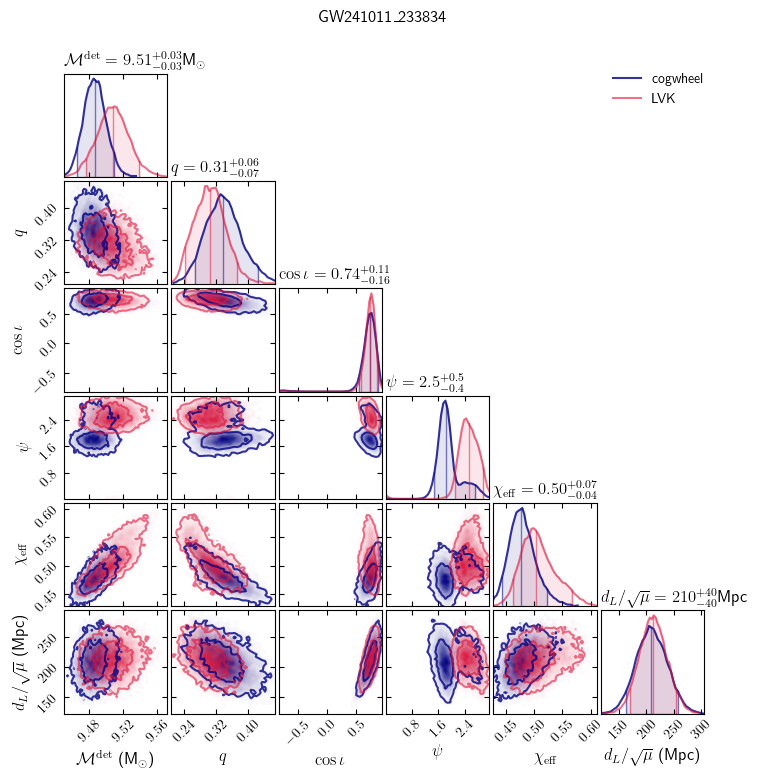

In [11]:
eventname = 'GW241011_233834'
# load our samples
event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
# load the LVK results
lvk_samples = helpers.load_lvk_samples(eventname)
cp = plot_cogwheel_lvk(samples, lvk_samples)
plt.gcf().suptitle(eventname)

### the other events

loaded posterior samples for GW241011_233834 run 0
loaded posterior samples for GW241225_082815 run 0
couldn't find any LVK samples for GW241225_082815 (in GWTC-5.0 or GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW240930_035959 run 0
loaded posterior samples for GW250114_082203 run 0
couldn't find any LVK samples for GW250114_082203 (in GWTC-5.0 or GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW240921_201835 run 0
couldn't find any LVK samples for GW240921_201835 (in GWTC-5.0 or GWTC-4.0 or GWTC-2.1)
loaded posterior samples for GW241127_061008 run 0
loaded posterior samples for GW250119_190238 run 0
couldn't find any LVK samples for GW250119_190238 (in GWTC-5.0 or GWTC-4.0 or GWTC-2.1)


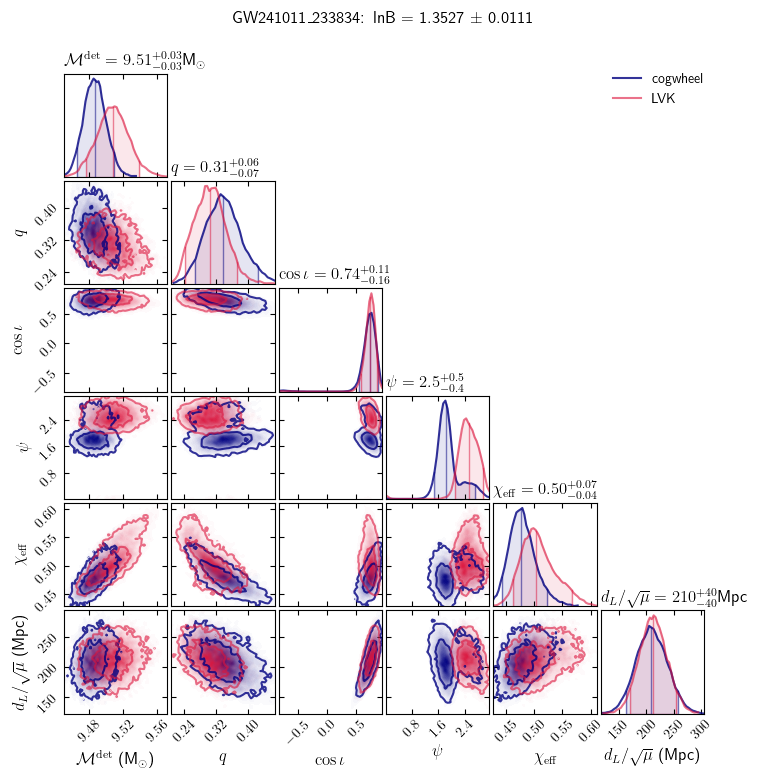

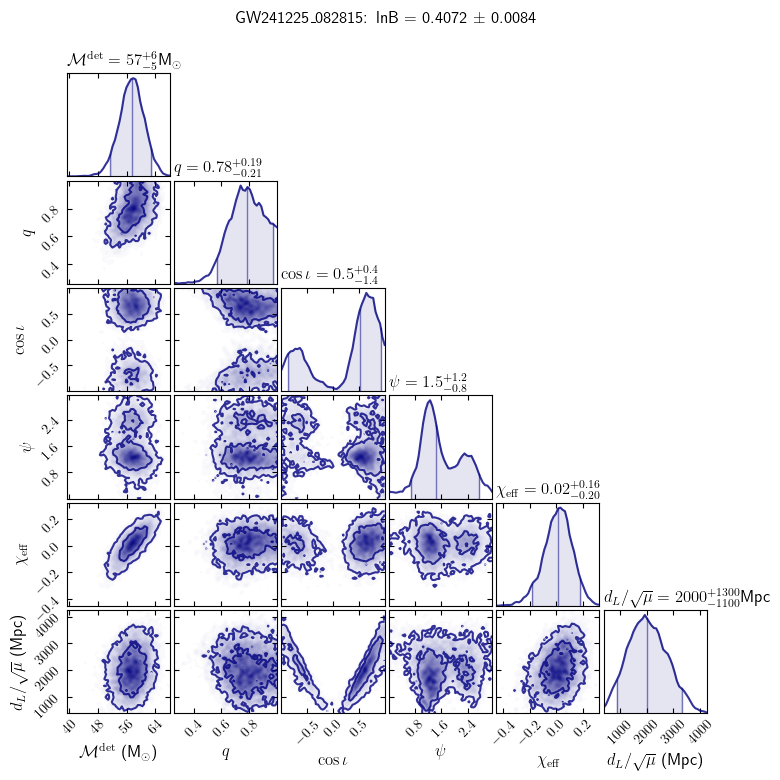

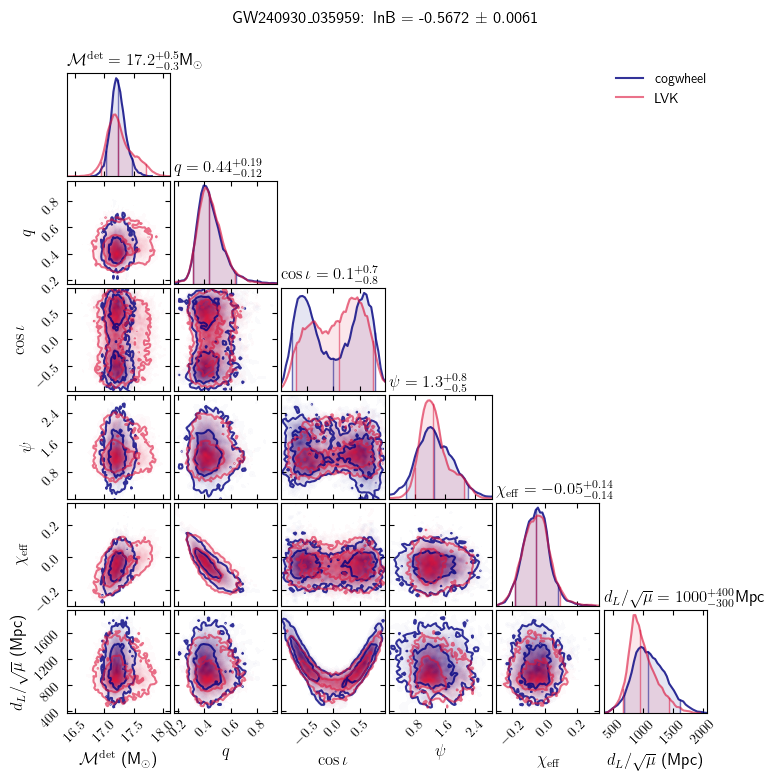

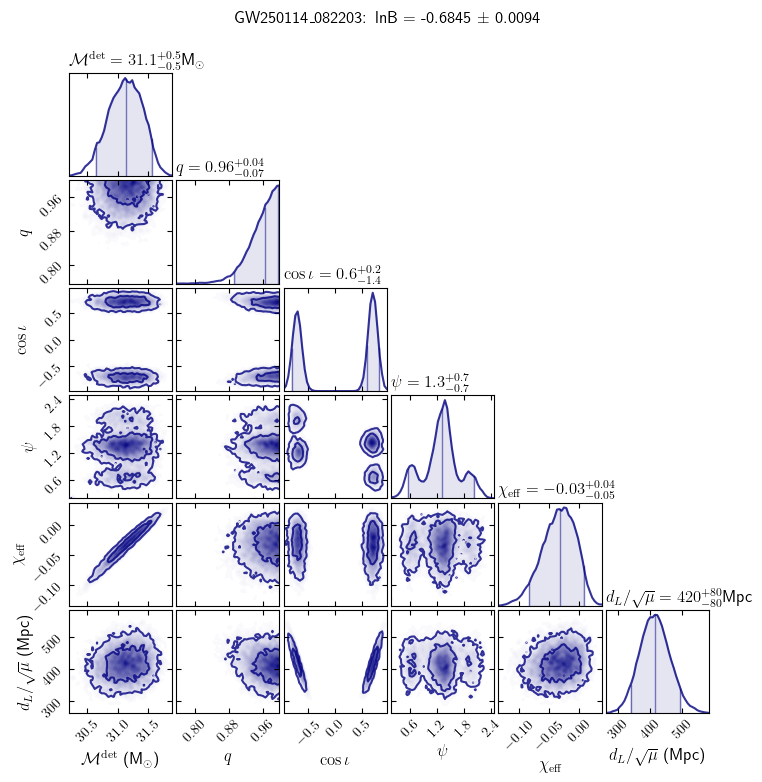

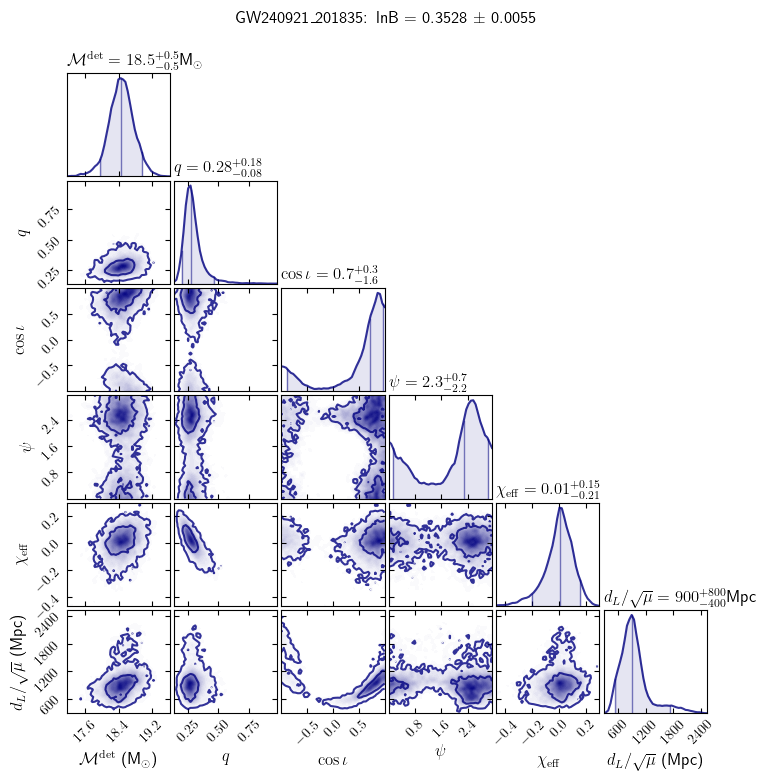

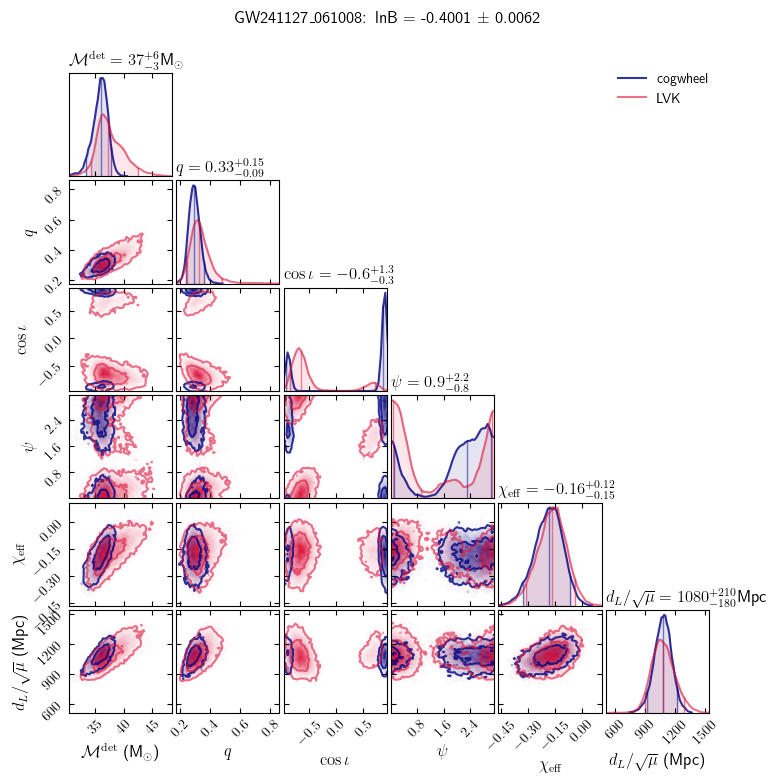

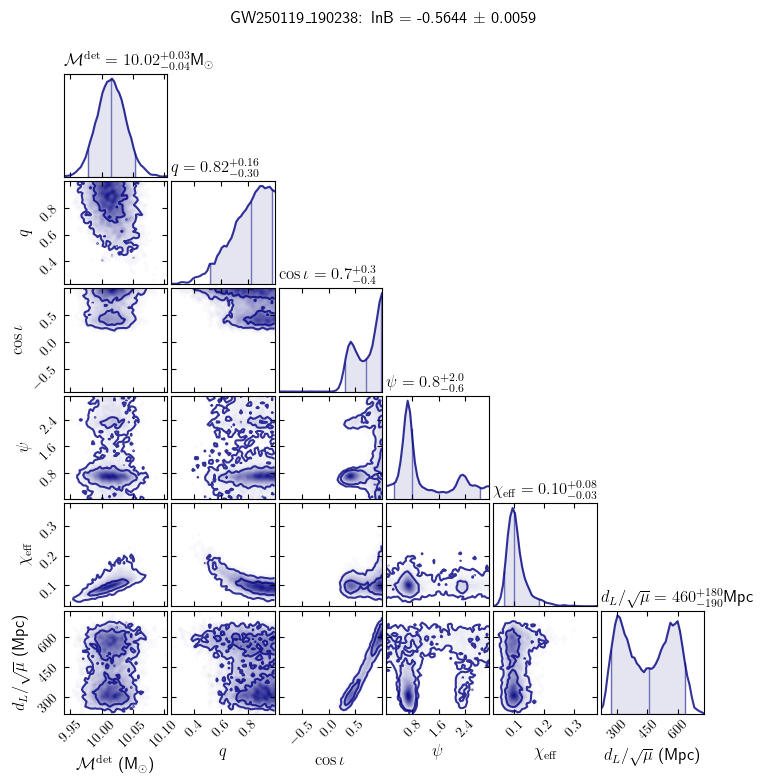

In [13]:
for eventname in eventnames:
    # load our samples
    event_data, samples, samples_dir = helpers.load_event_data_and_posterior_samples(os.path.join(resdir, eventname), eventname)
    # load the LVK results
    lvk_samples = helpers.load_lvk_samples(eventname)
    cp = plot_cogwheel_lvk(samples, lvk_samples)
    lnB, lnB_std = lnBayes[eventname]
    plt.gcf().suptitle(f"{eventname}: lnB = {lnB:.4f} ± {lnB_std:.4f}")